In [75]:
# Homework 8 - 4.
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

exoplanet_data = pd.read_csv('exoplanet_data.csv', comment = "#")

In [76]:
# What is the shape? 
print(exoplanet_data.shape) # the data has 583 rows and 92 columns --> a 92 x 583 matrix
# print all column titles
print(exoplanet_data.columns)
# 5 titles that i dont know the meaning of their name 
# radelim, gaiamager, masslim, tefferr1, radeerr2. 

(583, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

In [77]:
# 4.3 Reducing Data 
# database column names: 
# Planet Name = pl_name† --> desc: Planet name most commonly used in the literature
# Host Name = hostname† --> desc: Stellar name most commonly used in the literature
# Discovery Method = discoverymethod† --> desc: Method by which the planet was first identified
# Spectral Type = st_spectype --> desc: Classification of the star based on its spectral characteristics following the Morgan-Keenan system
# Equilibrium Temperature[K] = pl_eqt† --> desc: The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body
# Planet Mass or mass*sin(i)[jupiter mass] = pl_massj --> desc: Amount of matter contained in the planet, measured in units of masses of Jupiter

# What each name means in my own words: 
# planet name: the name given to a planet 
# host name: the name of the host star that the planet belongs to 
# discovery method: how the planet was found/discovery, the methods used
# spectral type: classification of a planet based on photospheric temperature
# Equilibrium temperature: the temperature at which heat exchange no longer occurs 
# planet mass[jupiter]: the mass of the planet measured in relation to Jupiter's mass. 


exoplanet_reduced = exoplanet_data[ 
    ["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]
    ]

exoplanet_reduced = exoplanet_reduced.dropna(axis=1) 


# Questions: 
# shape? 
print(exoplanet_reduced.shape) # a 3 x 583 matrix with 583 rows and 3 columns 

# first and last 5 entries 
print(f"{exoplanet_reduced.head()}\n{exoplanet_reduced.tail()}")

# print column titles 
print(exoplanet_reduced.columns)


(583, 3)
    pl_name hostname  discoverymethod
0   7 CMa c    7 CMa  Radial Velocity
1   7 CMa c    7 CMa  Radial Velocity
2  DMPP-1 b   DMPP-1  Radial Velocity
3  DMPP-1 b   DMPP-1  Radial Velocity
4  DMPP-1 c   DMPP-1  Radial Velocity
         pl_name   hostname  discoverymethod
578    bet Pic c    bet Pic  Radial Velocity
579    bet Pic c    bet Pic  Radial Velocity
580    bet Pic c    bet Pic  Radial Velocity
581  eps Ind A b  eps Ind A  Radial Velocity
582  eps Ind A b  eps Ind A  Radial Velocity
Index(['pl_name', 'hostname', 'discoverymethod'], dtype='object')


In [78]:
# 4.4 

exoplanet_reduced["discoverymethod"].value_counts()
# different methods: 
# transit, radial velocity, microlensing, imaging, transit timing variations, eclipse timing variations, disk kinematics, 
# transit has 392, microlensing has 61, radial velocity has 118, imaging: 6, transit timing: 3, eclipse timing: 2, disk kinematics: 2
# Transit has the most, disk kinematics has the least

# definitions of each: 
# transit: detects exoplanets by measuring the dip of a star's brightness as a planet pass infront of it
# radial velocity detects exoplanets by identifying tiny changes in a star's motion due to a planet's gravitational field
# microlensing detects exoplanets by observing the temporary brightening of a distant background star caused by the gravity of a closer foreground star acting as a lens. 
# imaging uses transit photometry or coronagraphs. 
# transit timing variations detect nontransiting exoplanets in a system by identifying slight, periodic deviations in the expected timing of a known planets transit. 
# eclipse timing variations discover exoplanets by monitoring binary star systems for irregular periodic shifts when eclipses occur. 





discoverymethod
Transit                      392
Radial Velocity              118
Microlensing                  61
Imaging                        6
Transit Timing Variations      3
Eclipse Timing Variations      2
Disk Kinematics                1
Name: count, dtype: int64

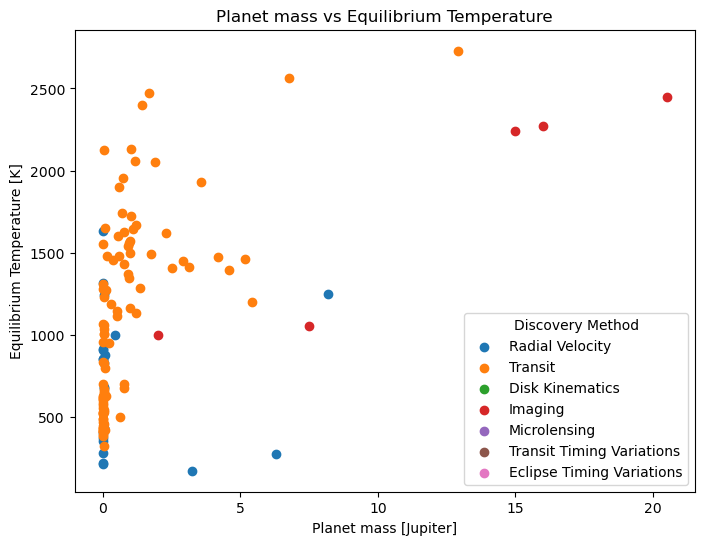

In [79]:
plt.figure(figsize=(8,6))

for method in exoplanet_data["discoverymethod"].unique(): 
    subset = exoplanet_data[exoplanet_data["discoverymethod"] == method]

    plt.scatter( 
        subset["pl_bmassj"], subset["pl_eqt"], label=method
    )



plt.xlabel("Planet mass [Jupiter]")
plt.ylabel("Equilibrium Temperature [K]")
plt.title("Planet mass vs Equilibrium Temperature")

plt.legend(title="Discovery Method") 


plt.show()

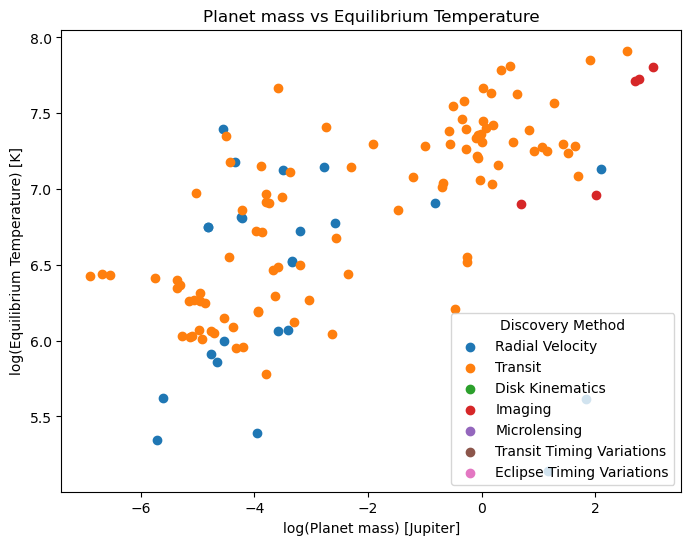

In [80]:
plt.figure(figsize=(8,6))

for method in exoplanet_data["discoverymethod"].unique(): 
    subset = exoplanet_data[exoplanet_data["discoverymethod"] == method]

    plt.scatter( 
        np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=method
    )

plt.xlabel("log(Planet mass) [Jupiter]")
plt.ylabel("log(Equilibrium Temperature) [K]")
plt.title("Planet mass vs Equilibrium Temperature")

plt.legend(title="Discovery Method") 


plt.show()

In [81]:
# Based on the plot, we can see that the imaging methods are more likely to be massive. 
# find the coldest planet mass larger than five Jupiter masses
def find_coldest(exoplanet_data) : 

    filtered_planets = exoplanet_data[exoplanet_data["pl_bmassj"] > 5] 

    coldest_row = filtered_planets.loc[filtered_planets["pl_eqt"].idxmin()]
    
    coldest_planet = str(coldest_row["pl_name"])
    coldest_temp = float(coldest_row["pl_eqt"])
    
    return coldest_planet, coldest_temp

print(find_coldest(exoplanet_data))
                

('eps Ind A b', 275.0)


In [82]:
print(exoplanet_data.loc[exoplanet_data["pl_name"] == "eps Ind A b"])
# its name is epsilon Indi Ab 
# its index is at row 581 
# its equilibrium temperature is 275 
# its mass is 6.31 jupiters
# it is orbiting a K5V star

         pl_name   hostname  default_flag  sy_snum  sy_pnum  discoverymethod  \
581  eps Ind A b  eps Ind A             1        3        1  Radial Velocity   
582  eps Ind A b  eps Ind A             0        3        1  Radial Velocity   

     disc_year         disc_facility              soltype  pl_controv_flag  \
581       2019  La Silla Observatory  Published Confirmed                0   
582       2019  La Silla Observatory  Published Confirmed                0   

     ... sy_vmagerr2  sy_kmag  sy_kmagerr1  sy_kmagerr2  sy_gaiamag  \
581  ...       -0.03    2.237         0.24        -0.24     4.34562   
582  ...       -0.03    2.237         0.24        -0.24     4.34562   

     sy_gaiamagerr1  sy_gaiamagerr2   rowupdate  pl_pubdate  releasedate  
581        0.007374       -0.007374  2024-08-07     2024-09   2024-08-07  
582        0.007374       -0.007374  2019-10-18     2019-12   2019-10-24  

[2 rows x 92 columns]


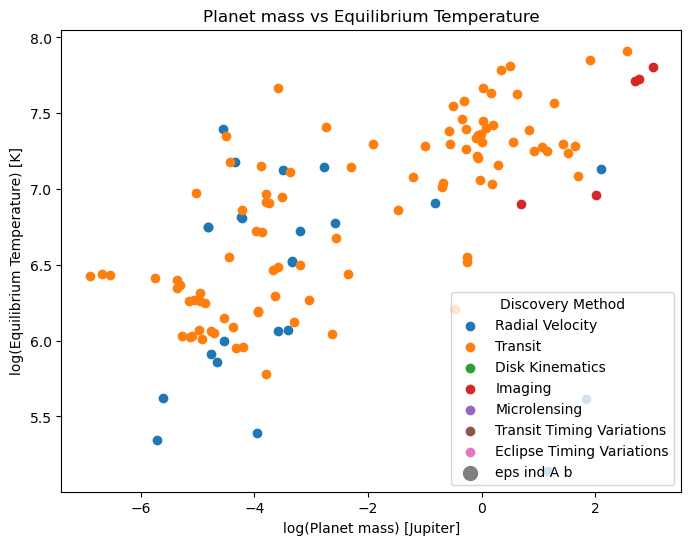

In [83]:
plt.figure(figsize=(8,6))

for method in exoplanet_data["discoverymethod"].unique(): 
    subset = exoplanet_data[exoplanet_data["discoverymethod"] == method]

    plt.scatter( 
        np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=method
    )

coldest_planet = exoplanet_data.loc[exoplanet_data["pl_name"] == "eps ind A b"]

plt.scatter(
    np.log(coldest_planet["pl_bmassj"]), np.log(coldest_planet["pl_eqt"]), color = "grey", s=100, marker="o", label="eps ind A b"
            )
        
plt.xlabel("log(Planet mass) [Jupiter]")
plt.ylabel("log(Equilibrium Temperature) [K]")
plt.title("Planet mass vs Equilibrium Temperature")

plt.legend(title="Discovery Method", loc = "best") 

plt.show()

In [84]:
# Nature paper Questions: 
# Title: "A temperature super-jupiter image with JWST in the mid-infrared."
# summary of abstract: data suggested that a giant planet was in orbit around a star. After collecting more data about this planet the data, specifically, radial and astrometric measurements were incosistent with the planet being giant, therefore the planet was name esp ind A b as there could be another planet orbting the same star that is much larger. After analyzing the temperature of the planet it was discovered that it is probably the only giant planet in the system.  
# Yes, our planet matches the exoplanet in the paper. 
# The planet is special because it is a Jupiter-sized planet that is very cold, whereas many Jupiter-sized planets are very hot.
# Yes, the mass and temperature of the planet stated in the paper match what we found, mass = 6.31 Jupiter masses, and temp being 275-280 K.

